# RSVP Tools Demo Notebook
This notebook demonstrates loading the `rsvp_tools` package, running experiments,
and visualizing basic results.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Try importing the package
from rsvp_tools import (
    StratumIndexEstimator, StratumIndexConfig,
    FiberNullPruner, FiberNullConfig,
    LamFlowWrapper, LamFlowConfig,
    TARTANLayer, TARTANConfig
)

print('Package imported successfully!')

Package imported successfully!


In [4]:
# ---------------------------------------------------------
# Test 1 — Simple model
# ---------------------------------------------------------
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
    def forward(self, x):
        return self.net(x)

model = TinyMLP()
x = torch.randn(8, 5)     # batch 8, input dim 5
y = torch.randint(0, 3, (8,))  # classification targets

print("Model initialized.")

# ---------------------------------------------------------
# Test 2 — Stratum Index Estimator
# ---------------------------------------------------------
sie = StratumIndexEstimator(model, StratumIndexConfig())
rank_est = sie(x)
print("Stratum index estimate:", rank_est.item())

# ---------------------------------------------------------
# Test 3 — Fiber Null Pruner
# ---------------------------------------------------------
fnp = FiberNullPruner(model, FiberNullConfig(eps=1e-4))
null_val = fnp(x)
print("Fiber-null value:", float(null_val))

# ---------------------------------------------------------
# Test 4 — LamFlowWrapper
# ---------------------------------------------------------
criterion = nn.CrossEntropyLoss()
lam_model = LamFlowWrapper(model, criterion, LamFlowConfig(lam_weight=1e-3))

loss = lam_model(x, y)
print("LamFlow loss:", float(loss))

loss.backward()
print("LamFlow backward pass OK")

# ---------------------------------------------------------
# Test 5 — TARTAN Layer
# ---------------------------------------------------------
tartan = TARTANLayer(dim=5, config=TARTANConfig(latent_dim=8))
xt = torch.randn(8, 5)

out_tartan = tartan(xt)
print("TARTAN output shape:", out_tartan.shape)
print("TARTAN memory now:", tartan.memory.detach().numpy())

print("\nAll RSVP Tools — tests executed successfully.")


Model initialized.
Stratum index estimate: 3.0
Fiber-null value: 2.0
LamFlow loss: 1.0801901817321777
LamFlow backward pass OK
TARTAN output shape: torch.Size([8, 5])
TARTAN memory now: [0. 0. 0. 0. 0. 0. 0. 0.]

All RSVP Tools — tests executed successfully.


In [5]:
si = StratumIndexEstimator(StratumIndexConfig())

print("Available attributes:\n")
for name in dir(si):
    if not name.startswith("_"):
        print(" -", name)


Available attributes:

 - T_destination
 - add_module
 - apply
 - bfloat16
 - buffers
 - call_super_init
 - children
 - config
 - cpu
 - cuda
 - double
 - dump_patches
 - eval
 - extra_repr
 - float
 - forward
 - get_buffer
 - get_extra_state
 - get_parameter
 - get_submodule
 - half
 - ipu
 - load_state_dict
 - model
 - modules
 - named_buffers
 - named_children
 - named_modules
 - named_parameters
 - parameters
 - register_backward_hook
 - register_buffer
 - register_forward_hook
 - register_forward_pre_hook
 - register_full_backward_hook
 - register_full_backward_pre_hook
 - register_load_state_dict_post_hook
 - register_module
 - register_parameter
 - register_state_dict_pre_hook
 - requires_grad_
 - set_extra_state
 - share_memory
 - state_dict
 - to
 - to_empty
 - train
 - training
 - type
 - xpu
 - zero_grad


Stratum Index: 5.0
Fiber Null: 5.0
LamFlow Loss: 1.6724570989608765
TARTAN output shape: torch.Size([8, 5])
TARTAN memory: [0. 0. 0. 0. 0. 0. 0. 0.]


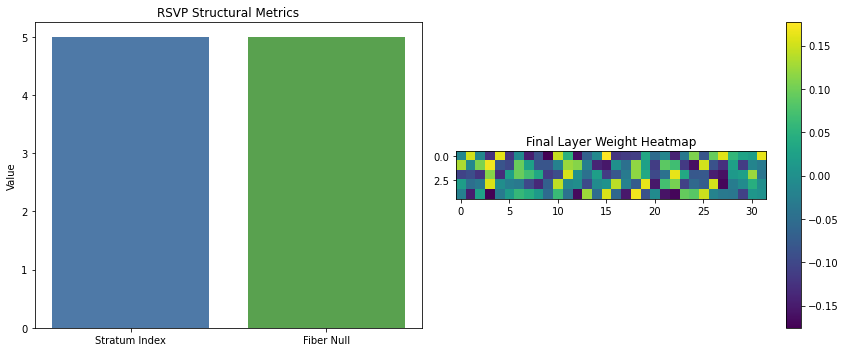

In [9]:
# -------------------------------------------------------
# Model + Inputs
# -------------------------------------------------------
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 5)
)

x = torch.randn(64, 10)
y = torch.randint(0, 5, (64,))

criterion = nn.CrossEntropyLoss()

# -------------------------------------------------------
# Stratum Index 
# -------------------------------------------------------
si = StratumIndexEstimator(model, StratumIndexConfig())
stratum_value = si(x)     
print("Stratum Index:", stratum_value.item())

# -------------------------------------------------------
# Fiber Null (FIXED)
# -------------------------------------------------------
fn = FiberNullPruner(model, FiberNullConfig())
fiber_null = fn(x)
print("Fiber Null:", fiber_null.item())


# -------------------------------------------------------
# LamFlow 
# -------------------------------------------------------
lam_model = LamFlowWrapper(model, criterion, LamFlowConfig(lam_weight=1e-2))
loss = lam_model(x, y)
loss.backward()
print("LamFlow Loss:", loss.item())

# -------------------------------------------------------
# TARTAN  
# -------------------------------------------------------
tartan = TARTANLayer(
    dim=5, 
    config=TARTANConfig(latent_dim=8, trajectory_smoothing=0.1)
)

tartan_out = tartan(torch.randn(8, 5))
tartan_memory = tartan.memory.detach().numpy()

print("TARTAN output shape:", tartan_out.shape)
print("TARTAN memory:", tartan_memory)


# -------------------------------------------------------
# Visualization
# -------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Bar Plot of Metrics ---
axs[0].bar(["Stratum Index", "Fiber Null"], 
           [stratum_value.item(), fiber_null.item()],
           color=["#4e79a7", "#59a14f"])
axs[0].set_title("RSVP Structural Metrics")
axs[0].set_ylabel("Value")

# --- Right: Heatmap of Last-Layer Weights ---
last_weight = model[-1].weight.detach().numpy()
im = axs[1].imshow(last_weight, cmap="viridis")
axs[1].set_title("Final Layer Weight Heatmap")
plt.colorbar(im, ax=axs[1])

plt.tight_layout()
plt.show()
